# 1. Environment Setup and Data Preprocessing
In this section, we initialize the analytical environment by importing essential libraries such as **Pandas**, **NumPy**, and **Seaborn**. We load the primary dataset, which is a merged collection of Steam metadata and global video game sales records. Additionally, we implement a custom parsing function to transform the `owners_range` string into a conservative numerical estimate (`min_owners`) for quantitative modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

df_main = pd.read_csv('Data/games_vgsales_matched.csv')
df_genres = pd.read_csv('Data/genres_clean.csv')

def extract_min_owners(range_str):
    if pd.isna(range_str):
        return 0
    try:
        min_val = str(range_str).replace(',', '').split(' .. ')[0]
        return int(min_val)
    except:
        return 0

df_main['min_owners'] = df_main['owners_range'].apply(extract_min_owners)

# 2. Exploratory Data Analysis (EDA)
Before deep-diving into strategic modeling, we perform a high-level data integrity check. This step involves inspecting the structure of the merged 1,854 entries to ensure that key performance indicators (KPIs)—such as global sales, pricing, and publisher metadata—are correctly formatted and free of critical missing values.

In [2]:
print("--- Dataset Information ---")
df_main.info()

print("\n--- Main Table Preview ---")
display(df_main.head())

print("\n--- Genre Table Preview ---")
display(df_genres.head())

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1854 entries, 0 to 1853
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   app_id           1854 non-null   int64  
 1   name             1854 non-null   object 
 2   release_date     1854 non-null   object 
 3   is_free          1854 non-null   int64  
 4   developer        1852 non-null   object 
 5   publisher        1852 non-null   object 
 6   owners_range     1852 non-null   object 
 7   price            1638 non-null   float64
 8   vg_match_score   1854 non-null   float64
 9   vg_name          1854 non-null   object 
 10  vg_na_sales      1854 non-null   float64
 11  vg_eu_sales      1854 non-null   float64
 12  vg_jp_sales      1854 non-null   float64
 13  vg_other_sales   1854 non-null   float64
 14  vg_global_sales  1854 non-null   float64
 15  vg_platform      1854 non-null   object 
 16  min_owners       1854 non-null  

,app_id,name,release_date,is_free,developer,publisher,owners_range,price,vg_match_score,vg_name,vg_na_sales,vg_eu_sales,vg_jp_sales,vg_other_sales,vg_global_sales,vg_platform,min_owners
0,342990,15 Days,4/1/2015,0,House of Tales,HandyGames,"20,000 .. 50,000",9.99,100.0,15 Days,0.00,0.01,0.0,0.00,0.01,PC,20000
1,33730,18 Wheels of Steel: Extreme Trucker,9/23/2009,0,N,Cosmi Valusoft,"20,000 .. 50,000",9.99,100.0,18 Wheels of Steel: Extreme Trucker,0.00,0.02,0.0,0.00,0.02,PC,20000
2,362780,18 Wheels of Steel: Extreme Trucker 2,5/8/2015,0,SCS Software,Cosmi Valusoft,"0 .. 20,000",9.99,100.0,18 Wheels of Steel: Extreme Trucker 2,0.08,0.02,0.0,0.01,0.11,PC,0
3,47000,4 Elements,7/12/2010,0,Playrix Entertainment,Playrix Entertainment,"50,000 .. 100,000",0.00,100.0,4 Elements,0.00,0.04,0.0,0.01,0.05,PC,50000
4,778080,40 Winks,10/22/2018,0,Eurocom,"Piko Interactive LLC, Bleem!","0 .. 20,000",13.99,100.0,40 Winks,0.17,0.12,0.0,0.02,0.31,PS,0



--- Genre Table Preview ---


,app_id,genre
0,10,Action
1,20,Action
2,30,Action
3,40,Action
4,50,Action


# 3. Publisher Portfolio Analysis
To understand market positioning, we analyze the top 10 publishers by player base. By merging the main dataset with genre classifications, we generate a **Portfolio Heatmap**. This visualization reveals how sales are distributed across different game genres, highlighting whether a publisher follows a "Generalist" approach or focuses on specific market segments.

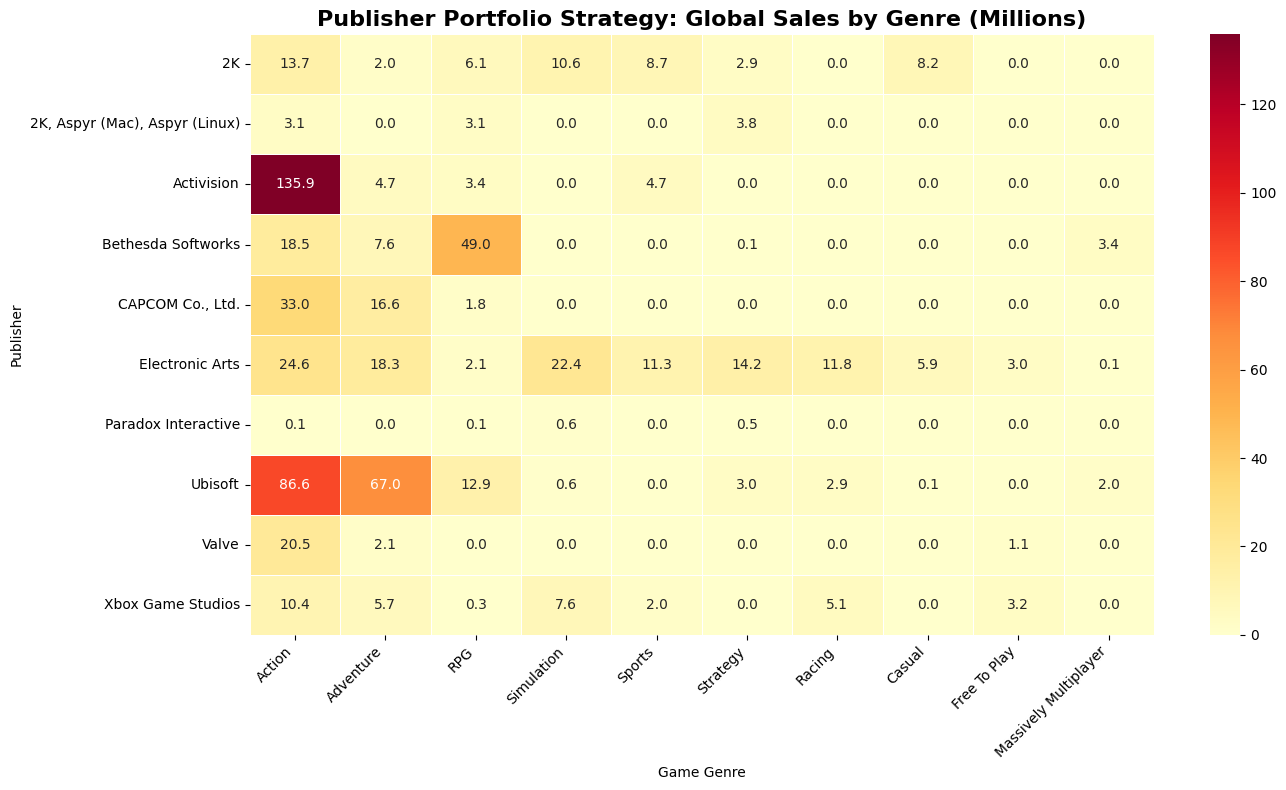

In [3]:
publisher_stats = df_main.groupby('publisher').agg(
    game_count=('app_id', 'count'),
    avg_price=('price', 'mean'),
    total_players=('min_owners', 'sum')
).reset_index()

top_10_pubs = publisher_stats[publisher_stats['game_count'] >= 3].sort_values(by='total_players', ascending=False).head(10)['publisher'].tolist()

df_merged = pd.merge(df_main, df_genres, on='app_id', how='inner')
df_top10_merged = df_merged[df_merged['publisher'].isin(top_10_pubs)]

sales_portfolio = pd.pivot_table(
    df_top10_merged, 
    values='vg_global_sales', 
    index='publisher', 
    columns='genre', 
    aggfunc='sum', 
    fill_value=0
)

top_genres = sales_portfolio.sum(axis=0).nlargest(10).index
sales_portfolio_top = sales_portfolio[top_genres]

plt.figure(figsize=(14, 8))
sns.heatmap(sales_portfolio_top, cmap="YlOrRd", annot=True, fmt=".1f", linewidths=.5)
plt.title("Publisher Portfolio Strategy: Global Sales by Genre (Millions)", fontsize=16, fontweight='bold')
plt.ylabel("Publisher")
plt.xlabel("Game Genre")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 4. Strategic Concentration: The HHI Framework
We apply the **Herfindahl-Hirschman Index (HHI)** to quantify the level of genre specialization for each publisher. The HHI is calculated as the sum of the squares of the sales shares across all genres:
$$HHI = \sum_{i=1}^{n} (\text{Market Share}_i)^2$$
The resulting **Publisher Strategy Matrix** maps concentration against financial performance, categorizing firms into **Diversified Giants** or **Specialized Powerhouses**.

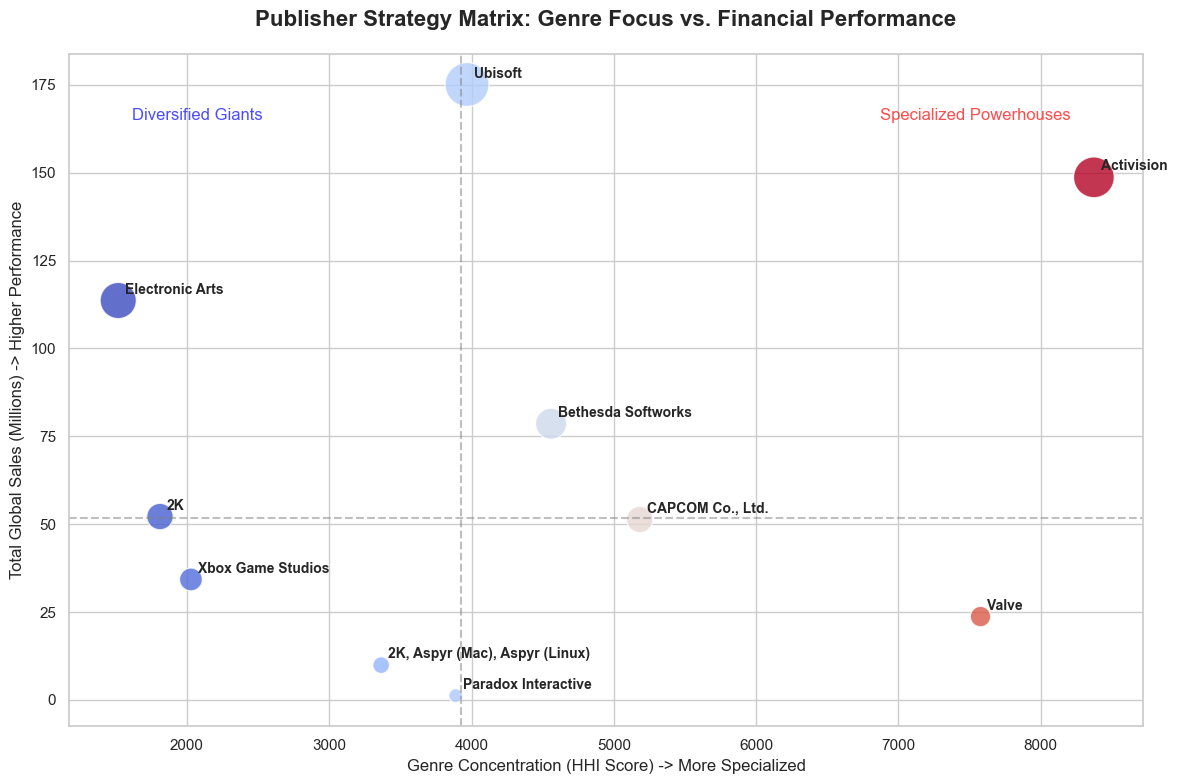

In [4]:
portfolio_shares = sales_portfolio.div(sales_portfolio.sum(axis=1), axis=0) * 100
hhi_scores = (portfolio_shares ** 2).sum(axis=1)

hhi_df = pd.DataFrame({
    'Total Global Sales (M)': sales_portfolio.sum(axis=1),
    'HHI Score': hhi_scores
}).round(2)

plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

x = hhi_df['HHI Score']
y = hhi_df['Total Global Sales (M)']
labels = hhi_df.index

sns.scatterplot(x=x, y=y, size=y, sizes=(100, 1000), hue=x, palette="coolwarm", legend=False, alpha=0.8)

for i, label in enumerate(labels):
    plt.annotate(label, (x.iloc[i], y.iloc[i]), xytext=(5, 5), textcoords='offset points', fontsize=10, fontweight='bold')

plt.axvline(x.median(), color='grey', linestyle='--', alpha=0.5)
plt.axhline(y.median(), color='grey', linestyle='--', alpha=0.5)

plt.title("Publisher Strategy Matrix: Genre Focus vs. Financial Performance", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Genre Concentration (HHI Score) -> More Specialized")
plt.ylabel("Total Global Sales (Millions) -> Higher Performance")

plt.text(x.min()+100, y.max()-10, 'Diversified Giants', fontsize=12, color='blue', alpha=0.7)
plt.text(x.max()-1500, y.max()-10, 'Specialized Powerhouses', fontsize=12, color='red', alpha=0.7)

plt.tight_layout()
plt.show()

# 5. Monetization Models and User Acquisition
Finally, we evaluate the impact of business models—specifically **Free-to-Play (F2P)** vs. **Paid**—on user acquisition efficiency. Through a comparative analysis of the overall market and a focused case study on **Valve**, we demonstrate how F2P models act as a "traffic funnel," significantly lowering the barrier to entry and fostering vast digital ecosystems.

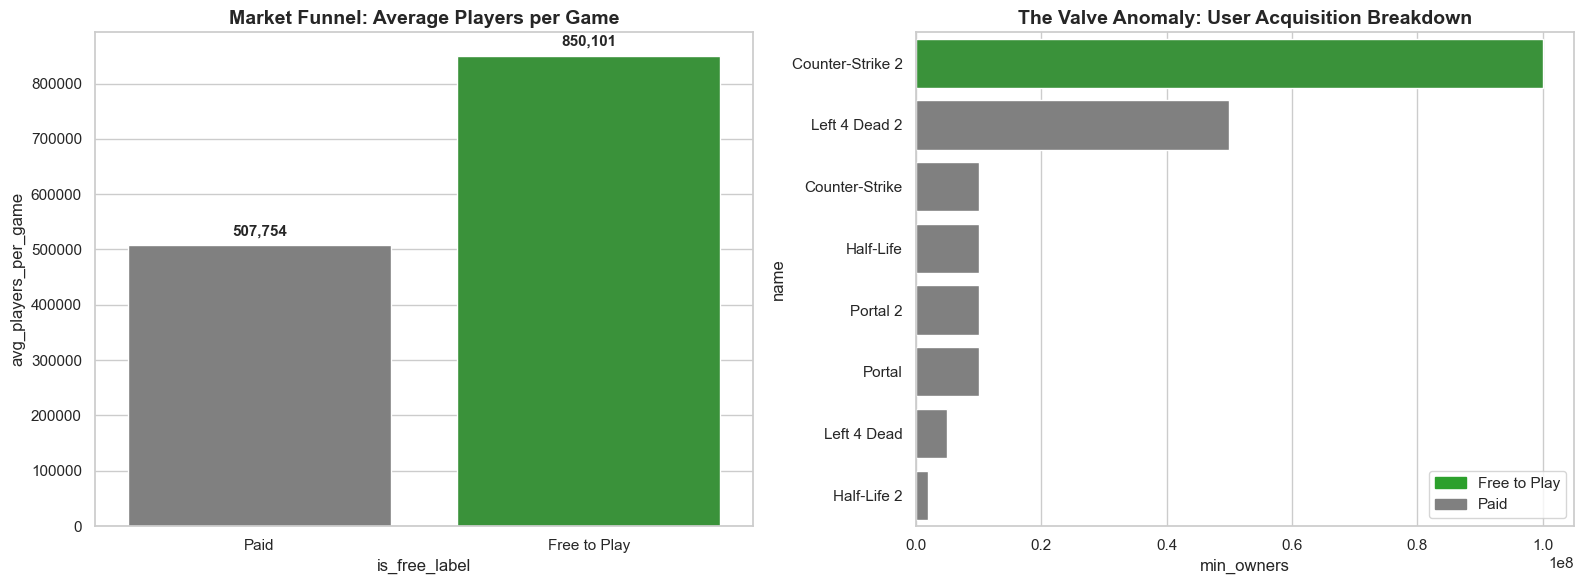

In [5]:
f2p_stats = df_main.groupby('is_free').agg(
    game_count=('app_id', 'count'),
    total_players=('min_owners', 'sum'),
).reset_index()

f2p_stats['avg_players_per_game'] = (f2p_stats['total_players'] / f2p_stats['game_count']).round(0)
f2p_stats['is_free_label'] = f2p_stats['is_free'].map({0: 'Paid', 1: 'Free to Play'})

valve_games = df_main[df_main['publisher'] == 'Valve'][['name', 'is_free', 'price', 'min_owners']].sort_values(by='min_owners', ascending=False)
valve_games['is_free_status'] = valve_games['is_free'].map({0: 'No', 1: 'Yes'})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=f2p_stats, x='is_free_label', y='avg_players_per_game', hue='is_free_label', legend=False, ax=axes[0], palette=['#808080', '#2ca02c'])
axes[0].set_title('Market Funnel: Average Players per Game', fontsize=14, fontweight='bold')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 5), textcoords='offset points')

valve_top8 = valve_games.head(8)
sns.barplot(data=valve_top8, x='min_owners', y='name', hue='is_free_status', dodge=False, ax=axes[1], palette={'Yes': '#2ca02c', 'No': '#808080'})
axes[1].set_title('The Valve Anomaly: User Acquisition Breakdown', fontsize=14, fontweight='bold')
axes[1].legend_.remove()
axes[1].legend(handles=[mpatches.Patch(color='#2ca02c', label='Free to Play'), mpatches.Patch(color='#808080', label='Paid')], loc='lower right')

plt.tight_layout()
plt.show()